## Importing Libraries

In [66]:
# Setting up the environment and silencing noisy logs
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TRANSFORMERS_NO_ADVISORY_WARNINGS'] = '1'
import warnings
warnings.filterwarnings('ignore')
import logging
logging.getLogger('transformers').setLevel(logging.ERROR)
logging.getLogger('tensorflow').setLevel(logging.ERROR)

import torch
import numpy as np
import pandas as pd
import seaborn as sns
import random, re, nltk, gensim
import matplotlib.pyplot as plt
import torch.nn as nn
from datasets import Dataset
from collections import Counter
from transformers import TrainingArguments, Trainer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
# Keras libraries for the BiLSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Bidirectional, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
# NLP text tool
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS
from gensim.models.phrases import Phrases, Phraser
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import RandomOverSampler
from transformers import DataCollatorWithPadding
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, ConfusionMatrixDisplay

In [67]:
# Fixing seeds so results are reproducible across runs
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
os.makedirs("figures", exist_ok = True)

## Dataset Loading
The dataset has been resulted from the merging of two separate datasets, FiQA and Financial PhraseBank combined into a ready to use csv file.

In [68]:
# Loading the financial sentiment dataset (FiQA + Financial PhraseBank merged)
df = pd.read_csv("financial_data.csv",  dtype = str)
# df = df.apply(lambda col: col.str.replace('$', r'\$', regex = False))

In [69]:
df

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral
...,...,...
5837,RISING costs have forced packaging producer Hu...,negative
5838,Nordic Walking was first used as a summer trai...,neutral
5839,"According shipping company Viking Line , the E...",neutral
5840,"In the building and home improvement trade , s...",neutral


## Exploratory Data Analysis
### Class Distribution
The three classifications in the dataset are not uniformly distributed as neutral statements account for around 60% of the data, whereas negative sentences make up only about 12%. Thus, the evaluation metric used here will be Macro-Averaged F1, which assigns equal weight to each of the three classes regardless of the number of cases in each.


In [70]:
df["Sentiment"].value_counts()

,count
Sentiment,
neutral,3130
positive,1852
negative,860


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5842 entries, 0 to 5841
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentence   5842 non-null   object
 1   Sentiment  5842 non-null   object
dtypes: object(2)
memory usage: 91.4+ KB


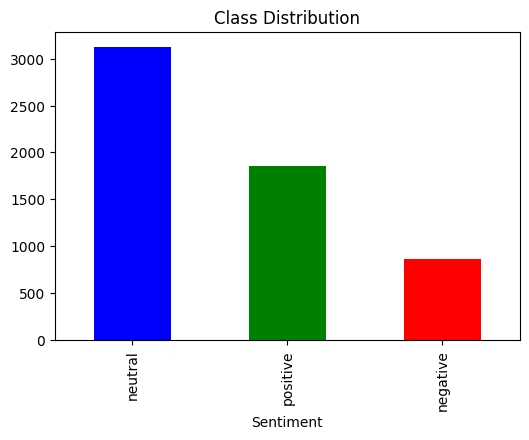

In [72]:
# Checking class imbalance
colors_map = ['blue', 'green', 'red']   # neutral, positive, negative (value_counts order)
plt.figure(figsize=(6,4))
df['Sentiment'].value_counts().plot(kind = 'bar', color = colors_map)
plt.title("Class Distribution")
plt.savefig("Class Distribution.png", dpi = 300, bbox_inches = 'tight')
plt.show()

### Data Cleaning
Stopword removal was used to preserve financial negation words like increase, decrease, up, down, etc. A standard pre-processing pipeline was applied which includes lowercasing, URL, HTML removal, tickers storing, monetary values preserving.

In [73]:
# Downloading NLTK stopwords and building a base stopword set
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [74]:
# Keeping financial words that carry sentiment
my_words = {'no','not','nor','against',
    'up','down','off','over','under',
    'loss','profit','gain','drop','rise','fall',
    'decline','increase','decrease', 'none', 'very',
    'negative','positive','risk','growth', 'to', 'from'}

stop_words = stop_words - my_words

In [75]:
lemmatizer = WordNetLemmatizer()
def processed_tokens(line):
    line = line.lower()
    line = re.sub(r'http\S+|www\S+', '', line)  # removing urls
    line = re.sub(r'@\w+', '', line)     # removing @mentions
    line = re.sub(r'^rt\s*', '', line)   # removing any 'RT' that appears at the start of retweets
    line = re.sub(r'&amp;', 'and', line)  # replacing html '&amp' with the word 'and'

    line = re.sub(r'\$\s+', '$', line)          # "$ 1.50" → "$1.50"
    line = re.sub(r'(\d),(\d)', r'\1\2', line)  # "1,000" → "1000"

    line = re.sub(r'\$(\d+(?:\.\d+)?)([kmbt]?)\b', lambda m: 'money_' + m.group(1).replace(',', '').replace('.', 'p') + m.group(2),line)
    #line = re.sub(r'\$(\d+)', r'money_\1', line)  # $2 → money_2
    line = re.sub(r'\$([a-z]+)\b', r'ticker_\1', line)  # Storing tickers like $AAPL -> ticker_aapl
    line = re.sub(r'#(\w+)', r' hashtag_\1 ', line)
    line = re.sub(r'(\d+)\s*%', r'percent_\1', line)
    line = re.sub(r'\+\s*(\d+(?:\.\d+)?)', r'gain_\1', line)
    line = re.sub(r'(?<!\w)-\s*(\d+(?:\.\d+)?)', r'loss_\1', line)
    line = re.sub(r'!+', ' exclam ', line)
    line = re.sub(r'\?+', ' question ', line)
    line = re.sub(r'[^a-z0-9_ ]', '', line)
    line = re.sub(r'\s+', ' ', line).strip()

    return line

In [77]:
def processed_texts(line):
    line = processed_tokens(line)
    tokens = re.findall(r'[a-z][a-z0-9_]*', line)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return tokens

def processed_texts_lstm(line):
    # leaving stopwords in for the BiLSTM
    line = processed_tokens(line)
    tokens = re.findall(r'[a-z][a-z0-9_]*', line)
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return tokens

In [78]:
df['Final_Tokens'] = df['Sentence'].apply(processed_texts)        # stopwords removed (LR / SVM)
df['LSTM_Tokens']  = df['Sentence'].apply(processed_texts_lstm)   # stopwords kept (BiLSTM)


In [79]:
df

,Sentence,Sentiment,Final_Tokens,LSTM_Tokens
0,The GeoSolutions technology will leverage Bene...,positive,"[geosolutions, technology, leverage, benefon, ...","[the, geosolutions, technology, will, leverage..."
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative,"[ticker_esi, low, down, money_1p50, to, money_...","[ticker_esi, on, low, down, money_1p50, to, mo..."
2,"For the last quarter of 2010 , Componenta 's n...",positive,"[last, quarter, componenta, net, sale, doubled...","[for, the, last, quarter, of, componenta, s, n..."
3,According to the Finnish-Russian Chamber of Co...,neutral,"[according, to, finnishrussian, chamber, comme...","[according, to, the, finnishrussian, chamber, ..."
4,The Swedish buyout firm has sold its remaining...,neutral,"[swedish, buyout, firm, sold, remaining, perce...","[the, swedish, buyout, firm, ha, sold, it, rem..."
...,...,...,...,...
5837,RISING costs have forced packaging producer Hu...,negative,"[rising, cost, forced, packaging, producer, hu...","[rising, cost, have, forced, packaging, produc..."
5838,Nordic Walking was first used as a summer trai...,neutral,"[nordic, walking, first, used, summer, trainin...","[nordic, walking, wa, first, used, a, a, summe..."
5839,"According shipping company Viking Line , the E...",neutral,"[according, shipping, company, viking, line, e...","[according, shipping, company, viking, line, t..."
5840,"In the building and home improvement trade , s...",neutral,"[building, home, improvement, trade, sale, dec...","[in, the, building, and, home, improvement, tr..."


Bigrams and trigrams are used to retain financial phrases such as “stock_market”,
“interest_rate_hike”, and “net_profit_margin”, which carries stronger sentiment signals than individual tokens

In [80]:
# Bigrams
tokens = df['Final_Tokens']
bigram = Phrases(tokens, min_count = 3, threshold = 10)
bigram_model = Phraser(bigram)
bigram_tokens = [bigram_model[doc] for doc in tokens]
# Trigrams (built on top of the bigram result)
trigram = Phrases(bigram_tokens, min_count = 3, threshold = 10)
trigram_model = Phraser(trigram)
df['Ngrams'] = [trigram_model[doc] for doc in bigram_tokens]

In [81]:
print(df['Ngrams'][1])

['ticker_esi', 'low', 'down', 'money_1p50', 'to', 'money_2p50', 'bk', 'real', 'possibility']


In [82]:
# Joining the tokens back into a single string for the TF-IDF vectoriser
df['Final_Text'] = df['Ngrams'].apply(lambda x: " ".join(x))
df['LSTM_Text']  = df['LSTM_Tokens'].apply(lambda x: " ".join(x))   # stopwords kept, for BiLSTM


In [83]:
df

,Sentence,Sentiment,Final_Tokens,LSTM_Tokens,Ngrams,Final_Text,LSTM_Text
0,The GeoSolutions technology will leverage Bene...,positive,"[geosolutions, technology, leverage, benefon, ...","[the, geosolutions, technology, will, leverage...","[geosolutions, technology, leverage, benefon, ...",geosolutions technology leverage benefon gps s...,the geosolutions technology will leverage bene...
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative,"[ticker_esi, low, down, money_1p50, to, money_...","[ticker_esi, on, low, down, money_1p50, to, mo...","[ticker_esi, low, down, money_1p50, to, money_...",ticker_esi low down money_1p50 to money_2p50 b...,ticker_esi on low down money_1p50 to money_2p5...
2,"For the last quarter of 2010 , Componenta 's n...",positive,"[last, quarter, componenta, net, sale, doubled...","[for, the, last, quarter, of, componenta, s, n...","[last_quarter, componenta, net_sale, doubled, ...",last_quarter componenta net_sale doubled to eu...,for the last quarter of componenta s net sale ...
3,According to the Finnish-Russian Chamber of Co...,neutral,"[according, to, finnishrussian, chamber, comme...","[according, to, the, finnishrussian, chamber, ...","[according_to, finnishrussian, chamber, commer...",according_to finnishrussian chamber commerce m...,according to the finnishrussian chamber of com...
4,The Swedish buyout firm has sold its remaining...,neutral,"[swedish, buyout, firm, sold, remaining, perce...","[the, swedish, buyout, firm, ha, sold, it, rem...","[swedish, buyout, firm, sold, remaining, perce...",swedish buyout firm sold remaining percent_sta...,the swedish buyout firm ha sold it remaining p...
...,...,...,...,...,...,...,...
5837,RISING costs have forced packaging producer Hu...,negative,"[rising, cost, forced, packaging, producer, hu...","[rising, cost, have, forced, packaging, produc...","[rising, cost, forced, packaging, producer, hu...",rising cost forced packaging producer huhtamak...,rising cost have forced packaging producer huh...
5838,Nordic Walking was first used as a summer trai...,neutral,"[nordic, walking, first, used, summer, trainin...","[nordic, walking, wa, first, used, a, a, summe...","[nordic, walking, first, used, summer, trainin...",nordic walking first used summer training meth...,nordic walking wa first used a a summer traini...
5839,"According shipping company Viking Line , the E...",neutral,"[according, shipping, company, viking, line, e...","[according, shipping, company, viking, line, t...","[according, shipping_company, viking_line, eu,...",according shipping_company viking_line eu deci...,according shipping company viking line the eu ...
5840,"In the building and home improvement trade , s...",neutral,"[building, home, improvement, trade, sale, dec...","[in, the, building, and, home, improvement, tr...","[building_home_improvement_trade, sale_decreas...",building_home_improvement_trade sale_decreased...,in the building and home improvement trade sal...


### WordCloud

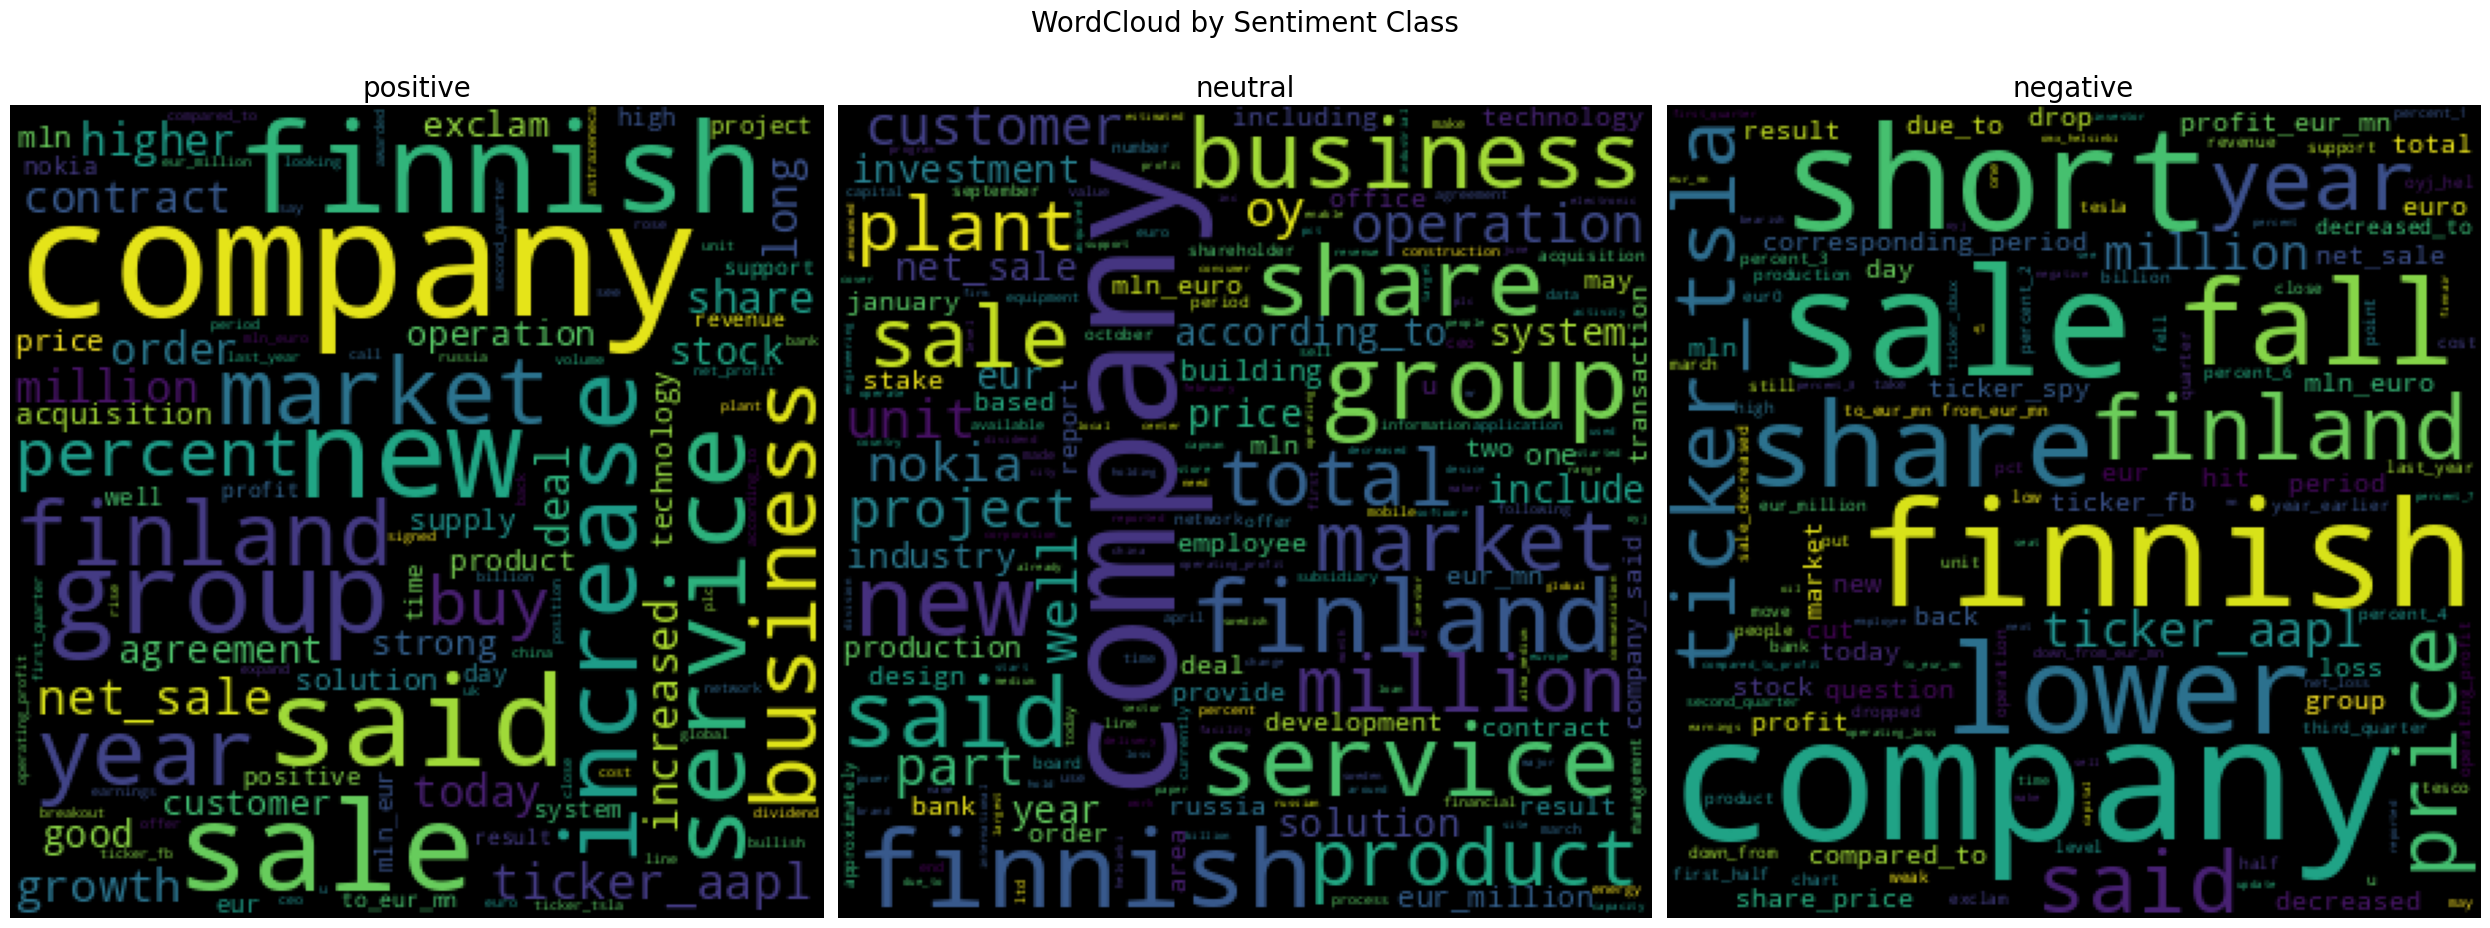

In [84]:
# Generating a word cloud per sentiment class
sentiments = ['positive', 'neutral', 'negative']
plt.figure(figsize=(25, 10))
for i, sentiment in enumerate(sentiments):
    text = " ".join(df[df['Sentiment'] == sentiment]['Final_Text'])
    wc = WordCloud(width = 300, height = 300).generate(text)
    plt.subplot(1, 3, i+1)
    plt.imshow(wc)
    plt.axis("off")
    plt.title(sentiment, fontsize=20)
plt.suptitle("WordCloud by Sentiment Class", fontsize = 20)
plt.tight_layout()
plt.savefig("Wordclouds.png", bbox_inches = 'tight')
plt.show()

### Label Encoding
Mapping the three sentiment classes to integers: negative : 0, neutral : 1, positive : 2.

In [85]:
# Mapping the three sentiment classes to integer labels for the classifiers
label_map = {"negative": 0, "neutral": 1, "positive": 2}
df["Label"] = df["Sentiment"].map(label_map)

In [86]:
df

,Sentence,Sentiment,Final_Tokens,LSTM_Tokens,Ngrams,Final_Text,LSTM_Text,Label
0,The GeoSolutions technology will leverage Bene...,positive,"[geosolutions, technology, leverage, benefon, ...","[the, geosolutions, technology, will, leverage...","[geosolutions, technology, leverage, benefon, ...",geosolutions technology leverage benefon gps s...,the geosolutions technology will leverage bene...,2
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative,"[ticker_esi, low, down, money_1p50, to, money_...","[ticker_esi, on, low, down, money_1p50, to, mo...","[ticker_esi, low, down, money_1p50, to, money_...",ticker_esi low down money_1p50 to money_2p50 b...,ticker_esi on low down money_1p50 to money_2p5...,0
2,"For the last quarter of 2010 , Componenta 's n...",positive,"[last, quarter, componenta, net, sale, doubled...","[for, the, last, quarter, of, componenta, s, n...","[last_quarter, componenta, net_sale, doubled, ...",last_quarter componenta net_sale doubled to eu...,for the last quarter of componenta s net sale ...,2
3,According to the Finnish-Russian Chamber of Co...,neutral,"[according, to, finnishrussian, chamber, comme...","[according, to, the, finnishrussian, chamber, ...","[according_to, finnishrussian, chamber, commer...",according_to finnishrussian chamber commerce m...,according to the finnishrussian chamber of com...,1
4,The Swedish buyout firm has sold its remaining...,neutral,"[swedish, buyout, firm, sold, remaining, perce...","[the, swedish, buyout, firm, ha, sold, it, rem...","[swedish, buyout, firm, sold, remaining, perce...",swedish buyout firm sold remaining percent_sta...,the swedish buyout firm ha sold it remaining p...,1
...,...,...,...,...,...,...,...,...
5837,RISING costs have forced packaging producer Hu...,negative,"[rising, cost, forced, packaging, producer, hu...","[rising, cost, have, forced, packaging, produc...","[rising, cost, forced, packaging, producer, hu...",rising cost forced packaging producer huhtamak...,rising cost have forced packaging producer huh...,0
5838,Nordic Walking was first used as a summer trai...,neutral,"[nordic, walking, first, used, summer, trainin...","[nordic, walking, wa, first, used, a, a, summe...","[nordic, walking, first, used, summer, trainin...",nordic walking first used summer training meth...,nordic walking wa first used a a summer traini...,1
5839,"According shipping company Viking Line , the E...",neutral,"[according, shipping, company, viking, line, e...","[according, shipping, company, viking, line, t...","[according, shipping_company, viking_line, eu,...",according shipping_company viking_line eu deci...,according shipping company viking line the eu ...,1
5840,"In the building and home improvement trade , s...",neutral,"[building, home, improvement, trade, sale, dec...","[in, the, building, and, home, improvement, tr...","[building_home_improvement_trade, sale_decreas...",building_home_improvement_trade sale_decreased...,in the building and home improvement trade sal...,1


### Train-Test Split
The split ensures the model learns enough from the majority of the training data (80%) while holding out unseen portion of test data (20%) to accurately evaluate its performance on new, real-world data. The traditional ML models will be required to access the Final Text data while Deep Learning models can take Raw Inputs.

In [87]:
# x is cleaned text (texts for LR and SVM)
# x_lstm is cleaned text with stopwords kept (for BiLSTM)
# x_dl is raw sentences (texts for FinBERT)
x = df['Final_Text']
x_lstm = df['LSTM_Text']
y = df['Label']
x_dl = df['Sentence']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = SEED, stratify = y)
x_lstm_train, x_lstm_test = x_lstm.iloc[x_train.index], x_lstm.iloc[x_test.index]
x_dl_train, x_dl_test = x_dl.iloc[x_train.index], x_dl.iloc[x_test.index]

print(f"\nTrain: {len(x_train)}, Test: {len(x_test)}")



Train: 4673, Test: 1169


### Imbalaned Class Handling : Random Oversampling
Random Oversampling is applied to duplicate existing minority-class examples in the training set. Indices are oversampled, the same resampled set is then applied to raw phrases (for deep learning models) and TF-IDF features (for classical models). As a result, the comparison is fair because all four models are trained on the same class-balanced dataset.

In [88]:
# Random Oversampling to balance the training set.
resample = RandomOverSampler(random_state = SEED)
rows = np.arange(len(x_train)).reshape(-1, 1)  # oversampling row positions instead of raw texts
sampled_rows, balanced_labels = resample.fit_resample(rows, y_train)

x_train_resampled = x_train.iloc[sampled_rows.flatten()]
x_lstm_train_resampled = x_lstm_train.iloc[sampled_rows.flatten()]
x_dl_train_resampled = x_dl_train.iloc[sampled_rows.flatten()]
y_train_resampled = balanced_labels


In [89]:
print(pd.Series(y_train_resampled).value_counts())

Label
0    2504
1    2504
2    2504
Name: count, dtype: int64


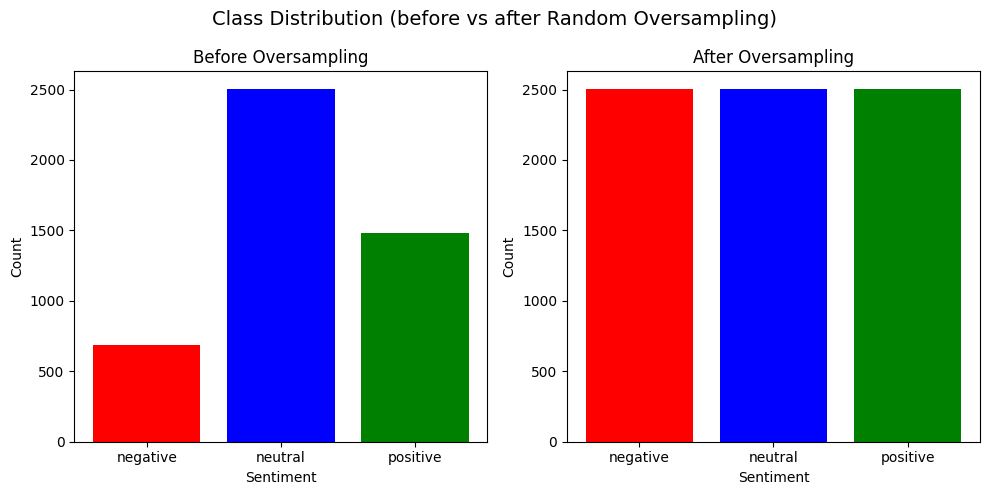

In [90]:
# class distribution before vs after oversampling
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

label_names = {0: 'negative', 1: 'neutral', 2: 'positive'}
bar_colors  = {'negative': 'red', 'neutral': 'blue', 'positive': 'green'}

# Before oversampling
before = pd.Series(y_train).value_counts().sort_index()
axes[0].bar([label_names[i] for i in before.index],
            before.values,
            color = [bar_colors[label_names[i]] for i in before.index])
axes[0].set_title("Before Oversampling")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Sentiment")

# After oversampling
after = pd.Series(y_train_resampled).value_counts().sort_index()
axes[1].bar([label_names[i] for i in after.index],
            after.values,
            color=[bar_colors[label_names[i]] for i in after.index])
axes[1].set_title("After Oversampling")
axes[1].set_ylabel("Count")
axes[1].set_xlabel("Sentiment")

fig.suptitle("Class Distribution (before vs after Random Oversampling)", fontsize=14)
plt.tight_layout()
plt.savefig("class_distribution_comparison.png", dpi = 300, bbox_inches = 'tight')
plt.show()

Function to compute and display model evaluation metrics including classification report and confusion matrix


In [91]:
# Returns accuracy, macro F1, and the confusion matrix
def evaluate_model(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    mac_f1 = f1_score(y_true, y_pred, average = 'macro')
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Macro F1:", mac_f1)
    print("\nClassification Report:")
    print(classification_report(
        y_true, y_pred, labels = [0, 1, 2],
        target_names = ["Negative", "Neutral", "Positive"]
    ))
    return acc, mac_f1, cm

### Traditional ML Models

Converting text into numerical features using TF-IDF, keeping up to 15000 features to balance representational richness against overfitting. TF (Term Frequency) is how often a word appears in a sentence and IDF (Inverse Document Frequency) is how important that word is across the dataset.

In [92]:
# Turning the text into numerical TF-IDF vectors (bigrams, trigrams)
# max_features caps vocabulary size to avoid overfitting on rare words
ml = TfidfVectorizer(max_features = 15000, ngram_range = (1,2), min_df = 2, max_df = 0.9)
x_train_ml = ml.fit_transform(x_train_resampled)
x_test_ml = ml.transform(x_test)

#### Logistic Regression
Logistic Regression serves as the primary baseline. GridSearchCV is used to search over the regularisation strength C and the penalty type to find the combination that maximises macro-averaged F1 on the training data via cross-validation.

In [132]:
lr_param_grid = {
    'C': [0.1, 1.0, 1.5],
    'penalty': ['l1', 'l2'],
    'solver': ['saga']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter = 15000, random_state = SEED),
    param_grid = lr_param_grid,
    scoring = 'f1_macro',
    cv = 5,
    n_jobs = -1,
    verbose = 1
)

lr_grid.fit(x_train_ml, y_train_resampled)
lr = lr_grid.best_estimator_
lr_pred = lr.predict(x_test_ml)
acc_lr, f1_lr, cm_lr = evaluate_model(y_test, lr_pred, "Logistic Regression")

Fitting 5 folds for each of 6 candidates, totalling 30 fits

Logistic Regression
Accuracy: 0.6723695466210436
Macro F1: 0.598597498908822

Classification Report:
              precision    recall  f1-score   support

    Negative       0.32      0.34      0.33       172
     Neutral       0.73      0.73      0.73       626
    Positive       0.74      0.72      0.73       371

    accuracy                           0.67      1169
   macro avg       0.60      0.60      0.60      1169
weighted avg       0.67      0.67      0.67      1169



#### Support Vector Machine
LinearSVC scales well with high-dimensional TF-IDF feature matrices. GridSearchCV explores different values of the regularisation parameter C and the loss function to optimise macro F1 via fold cross-validation.

In [133]:
svm_param_grid = {
    'C': [0.1, 1.0, 1.5, 2.0],
    'loss': ['hinge', 'squared_hinge']
}

svm_grid = GridSearchCV(
    LinearSVC(max_iter = 15000, random_state = SEED),
    param_grid = svm_param_grid,
    scoring = 'f1_macro',
    cv = 5,
    n_jobs = -1,
    verbose = 1
)
svm_grid.fit(x_train_ml, y_train_resampled)
svm = svm_grid.best_estimator_
svm_pred = svm.predict(x_test_ml)
acc_svm, f1_svm, cm_svm = evaluate_model(y_test, svm_pred, "SVM")

Fitting 5 folds for each of 8 candidates, totalling 40 fits

SVM
Accuracy: 0.6723695466210436
Macro F1: 0.5964343353666327

Classification Report:
              precision    recall  f1-score   support

    Negative       0.32      0.32      0.32       172
     Neutral       0.74      0.72      0.73       626
    Positive       0.72      0.76      0.74       371

    accuracy                           0.67      1169
   macro avg       0.59      0.60      0.60      1169
weighted avg       0.67      0.67      0.67      1169



### Deep Learning Models
#### Bidirectional LSTM
By processing sequences in both forward and backward directions, BiLSTMs enable the model to collect contextual dependencies from each token's left and right. This is especially useful for financial sentiment, because sentiment polarity generally relies on context, such as "profit declined" vs "decline in costs".

In [95]:
tokenizer_lstm = Tokenizer(num_words = 15000, oov_token = "<OOV>")
tokenizer_lstm.fit_on_texts(x_lstm_train_resampled)

x_train_lstm = tokenizer_lstm.texts_to_sequences(x_lstm_train_resampled)
x_test_lstm = tokenizer_lstm.texts_to_sequences(x_lstm_test)

# Padding all sequences to the same length
x_train_pad = pad_sequences(x_train_lstm, maxlen = 100, padding = 'post', truncating = 'post')  # max_len = 100
x_test_pad = pad_sequences(x_test_lstm, maxlen = 100, padding = 'post', truncating = 'post')  # max_len = 100

# Dropout / SpatialDropout1D to avoid overfitting
bilstm_model = Sequential([
    Input(shape = (100,)),
    Embedding(15000, 128, input_length = 100),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(64, return_sequences = True)),
    Bidirectional(LSTM(32)),
    Dropout(0.2),
    Dense(64, activation = 'relu'),
    Dropout(0.2),
    Dense(3, activation = 'softmax')   # 3 class softmax
])
bilstm_model.compile(loss = 'sparse_categorical_crossentropy',
              optimizer = Adam(learning_rate = 0.001),
              metrics = ['accuracy'])

bilstm_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 128)       │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 100, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,064,387 (7.88 MB)

 Trainable params: 2,064,387 (7.88 MB)

 Non-trainable params: 0 (0.00 B)

In [96]:
# Regularization to avoid overfitting
early_stop = EarlyStopping(monitor = 'val_loss', patience = 7, restore_best_weights = True)
y_train_arr = np.array(y_train_resampled)
y_test_arr  = np.array(y_test)
history = bilstm_model.fit(x_train_pad, y_train_arr,
                           epochs = 20, batch_size = 64,
                           validation_data = (x_test_pad, y_test_arr),
                           callbacks = early_stop, verbose = 1)

Epoch 1/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.5631 - loss: 0.9070 - val_accuracy: 0.6818 - val_loss: 0.7194
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.8600 - loss: 0.3982 - val_accuracy: 0.7023 - val_loss: 0.7397
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9215 - loss: 0.2373 - val_accuracy: 0.7083 - val_loss: 0.9724
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9310 - loss: 0.1964 - val_accuracy: 0.7057 - val_loss: 1.0379
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9333 - loss: 0.1794 - val_accuracy: 0.6749 - val_loss: 1.1561
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9388 - loss: 0.1602 - val_accuracy: 0.6801 - val_loss: 1.3498
Epoch 7/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9433 - loss: 0.1506 - val_accuracy: 0.6852 - val_loss: 1.2998
Epoch 8/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.9448 - loss: 0.1412 - val_accu

In [97]:
lstm_pred = bilstm_model.predict(x_test_pad)
y_pred_bilstm = np.argmax(lstm_pred, axis = 1)
acc_lstm, f1_lstm, cm_lstm = evaluate_model(y_test, y_pred_bilstm, "BiLSTM")

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

BiLSTM
Accuracy: 0.6817792985457656
Macro F1: 0.6448859104581216

Classification Report:
              precision    recall  f1-score   support

    Negative       0.38      0.66      0.48       172
     Neutral       0.81      0.69      0.75       626
    Positive       0.74      0.67      0.70       371

    accuracy                           0.68      1169
   macro avg       0.64      0.67      0.64      1169
weighted avg       0.73      0.68      0.70      1169



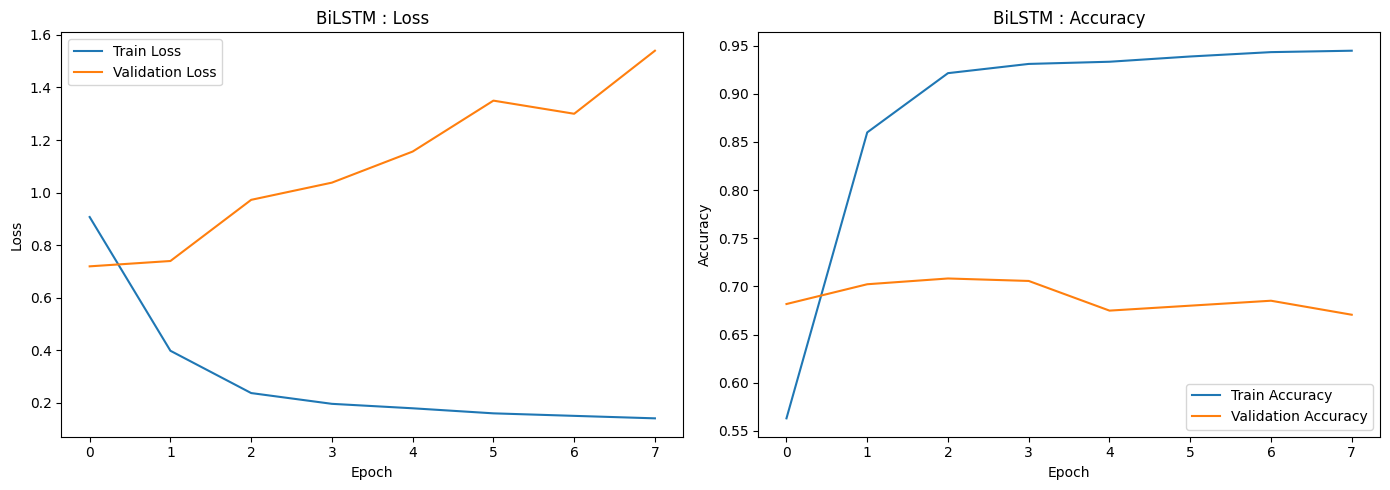

In [98]:
# BiLSTM Learning Curves — Training vs Validation
fig, axes = plt.subplots(1, 2, figsize = (14, 5))
# Loss
axes[0].plot(history.history['loss'], label = 'Train Loss')
axes[0].plot(history.history['val_loss'], label = 'Validation Loss')
axes[0].set_title("BiLSTM : Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
# Accuracy
axes[1].plot(history.history['accuracy'], label = 'Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label = 'Validation Accuracy')
axes[1].set_title("BiLSTM : Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("BiLSTM-loss-accuracy.png", bbox_inches = 'tight')
plt.show()

#### FinBERT
FinBERT has a significant advantage over general-purpose models for Financial Sentiment Analysis tasks due to domain-specific pre-training. The Hugging Face Trainer API is used to refine the model on the training set.


In [99]:
MODEL_NAME = "ProsusAI/finbert"
finbert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def df_str(x) :
    if pd.isna(x):
        return ""
    if isinstance(x, list):
        return " ".join(map(str, x))
    return str(x)

# FinBERT uses the raw sentences (x_dl_)
x_train_ds = x_dl_train_resampled.apply(df_str).reset_index(drop = True)
x_test_ds  = x_dl_test.apply(df_str).reset_index(drop = True)

y_train_ds = y_train_resampled.reset_index(drop = True)
y_test_ds  = pd.Series(y_test).reset_index(drop = True)

train_texts = x_train_ds.tolist()
test_texts  = x_test_ds.tolist()

In [100]:
# Wrapping the data for the Trainer API
train_ds = Dataset.from_dict({
    "text":  x_train_ds.tolist(),
    "label": y_train_ds.tolist()
})
test_ds = Dataset.from_dict({
    "text":  x_test_ds.tolist(),
    "label": y_test_ds.tolist()
})

In [101]:
print(type(train_ds[0]["text"]))
print(type(train_ds[0]["label"]))

<class 'str'>
<class 'int'>


In [102]:
# Tokenising function
tokenizer_finbert = AutoTokenizer.from_pretrained("ProsusAI/finbert")
def tokenize(batch):
    return finbert_tokenizer(
        batch["text"],
        padding = True,
        truncation = True,
        max_length = 128)

In [ ]:
# Running the tokenizer over the full train-test sets
train_ds = train_ds.map(tokenize, batched = True)
test_ds  = test_ds.map(tokenize, batched = True)

In [104]:
# PyTorch tensors for the trainer
train_ds.set_format(type = "torch", columns = ["input_ids", "attention_mask", "label"])
test_ds.set_format(type = "torch", columns = ["input_ids", "attention_mask", "label"])

In [ ]:
model_finbert = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert", num_labels = 3, ignore_mismatched_sizes = True)

In [106]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis = -1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average = 'macro')
    }

data_collator = DataCollatorWithPadding(tokenizer = finbert_tokenizer)

In [107]:
training_args = TrainingArguments(
    output_dir = "./finbert",
    num_train_epochs = 7,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size = 32,
    learning_rate = 2e-5,
    weight_decay = 0.01,
    warmup_ratio = 0.1,
    eval_strategy = "epoch",
    save_strategy = "epoch",
    load_best_model_at_end = True,
    logging_steps = 50, seed = SEED,
    metric_for_best_model = "macro_f1")

In [108]:
trainer = Trainer(
    model = model_finbert,
    args = training_args,
    train_dataset = train_ds,
    eval_dataset = test_ds,
    compute_metrics = compute_metrics,
    data_collator = data_collator)
trainer.train()

{'loss': '2.772', 'grad_norm': '16.21', 'learning_rate': '2.979e-06', 'epoch': '0.1064'}
{'loss': '1.61', 'grad_norm': '16.13', 'learning_rate': '6.018e-06', 'epoch': '0.2128'}
{'loss': '0.8833', 'grad_norm': '9.842', 'learning_rate': '9.058e-06', 'epoch': '0.3191'}
{'loss': '0.6591', 'grad_norm': '9.223', 'learning_rate': '1.21e-05', 'epoch': '0.4255'}
{'loss': '0.5031', 'grad_norm': '7.253', 'learning_rate': '1.514e-05', 'epoch': '0.5319'}
{'loss': '0.4662', 'grad_norm': '10.83', 'learning_rate': '1.818e-05', 'epoch': '0.6383'}
{'loss': '0.4342', 'grad_norm': '9.729', 'learning_rate': '1.986e-05', 'epoch': '0.7447'}
{'loss': '0.4462', 'grad_norm': '7.372', 'learning_rate': '1.953e-05', 'epoch': '0.8511'}
{'loss': '0.3449', 'grad_norm': '6.937', 'learning_rate': '1.919e-05', 'epoch': '0.9574'}
{'eval_loss': '0.4711', 'eval_accuracy': '0.8024', 'eval_macro_f1': '0.7725', 'eval_runtime': '7.649', 'eval_samples_per_second': '152.8', 'eval_steps_per_second': '4.837', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.325', 'grad_norm': '13.29', 'learning_rate': '1.885e-05', 'epoch': '1.064'}
{'loss': '0.2936', 'grad_norm': '13.5', 'learning_rate': '1.851e-05', 'epoch': '1.17'}
{'loss': '0.2644', 'grad_norm': '25.97', 'learning_rate': '1.818e-05', 'epoch': '1.277'}
{'loss': '0.3061', 'grad_norm': '2.545', 'learning_rate': '1.784e-05', 'epoch': '1.383'}
{'loss': '0.2843', 'grad_norm': '5.434', 'learning_rate': '1.75e-05', 'epoch': '1.489'}
{'loss': '0.2959', 'grad_norm': '2.599', 'learning_rate': '1.716e-05', 'epoch': '1.596'}
{'loss': '0.268', 'grad_norm': '18.46', 'learning_rate': '1.683e-05', 'epoch': '1.702'}
{'loss': '0.2537', 'grad_norm': '5.622', 'learning_rate': '1.649e-05', 'epoch': '1.809'}
{'loss': '0.2908', 'grad_norm': '5.602', 'learning_rate': '1.615e-05', 'epoch': '1.915'}
{'eval_loss': '0.5917', 'eval_accuracy': '0.8015', 'eval_macro_f1': '0.7701', 'eval_runtime': '7.65', 'eval_samples_per_second': '152.8', 'eval_steps_per_second': '4.837', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.2523', 'grad_norm': '1.506', 'learning_rate': '1.581e-05', 'epoch': '2.021'}
{'loss': '0.2001', 'grad_norm': '16.5', 'learning_rate': '1.547e-05', 'epoch': '2.128'}
{'loss': '0.2013', 'grad_norm': '3.622', 'learning_rate': '1.514e-05', 'epoch': '2.234'}
{'loss': '0.1939', 'grad_norm': '25.8', 'learning_rate': '1.48e-05', 'epoch': '2.34'}
{'loss': '0.2311', 'grad_norm': '1.391', 'learning_rate': '1.446e-05', 'epoch': '2.447'}
{'loss': '0.1996', 'grad_norm': '14.7', 'learning_rate': '1.412e-05', 'epoch': '2.553'}
{'loss': '0.2055', 'grad_norm': '3.769', 'learning_rate': '1.379e-05', 'epoch': '2.66'}
{'loss': '0.1907', 'grad_norm': '1.297', 'learning_rate': '1.345e-05', 'epoch': '2.766'}
{'loss': '0.1793', 'grad_norm': '1.595', 'learning_rate': '1.311e-05', 'epoch': '2.872'}
{'loss': '0.1866', 'grad_norm': '1.88', 'learning_rate': '1.277e-05', 'epoch': '2.979'}
{'eval_loss': '0.6368', 'eval_accuracy': '0.7938', 'eval_macro_f1': '0.7617', 'eval_runtime': '7.636', 'eval_samples_

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.1072', 'grad_norm': '1.275', 'learning_rate': '2.979e-06', 'epoch': '6.064'}
{'loss': '0.147', 'grad_norm': '1.094', 'learning_rate': '2.641e-06', 'epoch': '6.17'}
{'loss': '0.1327', 'grad_norm': '0.4765', 'learning_rate': '2.303e-06', 'epoch': '6.277'}
{'loss': '0.144', 'grad_norm': '3.41', 'learning_rate': '1.966e-06', 'epoch': '6.383'}
{'loss': '0.1295', 'grad_norm': '1.239', 'learning_rate': '1.628e-06', 'epoch': '6.489'}
{'loss': '0.137', 'grad_norm': '4.218', 'learning_rate': '1.29e-06', 'epoch': '6.596'}
{'loss': '0.1242', 'grad_norm': '1.386', 'learning_rate': '9.524e-07', 'epoch': '6.702'}
{'loss': '0.1307', 'grad_norm': '2.717', 'learning_rate': '6.147e-07', 'epoch': '6.809'}
{'loss': '0.1234', 'grad_norm': '1.438', 'learning_rate': '2.769e-07', 'epoch': '6.915'}
{'eval_loss': '0.9726', 'eval_accuracy': '0.7853', 'eval_macro_f1': '0.7381', 'eval_runtime': '7.651', 'eval_samples_per_second': '152.8', 'eval_steps_per_second': '4.836', 'epoch': '7'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '1094', 'train_samples_per_second': '48.06', 'train_steps_per_second': '3.007', 'train_loss': '0.277', 'epoch': '7'}


TrainOutput(global_step=3290, training_loss=0.276960319153806, metrics={'train_runtime': 1094.0971, 'train_samples_per_second': 48.062, 'train_steps_per_second': 3.007, 'train_loss': 0.276960319153806, 'epoch': 7.0})

In [109]:
# Getting predictions on the test set from the fine-tuned model
pred_out = trainer.predict(test_ds)
finbert_pred = np.argmax(pred_out.predictions, axis = 1)

In [110]:
acc_fin, f1_fin, cm_fin = evaluate_model(y_test_ds, finbert_pred, "FinBERT")


FinBERT
Accuracy: 0.8032506415739948
Macro F1: 0.7732323077150663

Classification Report:
              precision    recall  f1-score   support

    Negative       0.51      0.81      0.63       172
     Neutral       0.94      0.76      0.84       626
    Positive       0.83      0.88      0.86       371

    accuracy                           0.80      1169
   macro avg       0.76      0.82      0.77      1169
weighted avg       0.84      0.80      0.81      1169



In [112]:
# Train/eval loss and metrics from log history
train_loss, train_steps = [], []
eval_loss, eval_acc, eval_f1, eval_epochs = [], [], [], []

for log in trainer.state.log_history:
    if 'loss' in log and 'eval_loss' not in log and 'step' in log:
        train_loss.append(log['loss'])
        train_steps.append(log['step'])
    if 'eval_loss' in log:
        eval_loss.append(log['eval_loss'])
        eval_acc.append(log.get('eval_accuracy', None))
        eval_f1.append(log.get('eval_macro_f1', None))
        eval_epochs.append(log.get('epoch', 0))

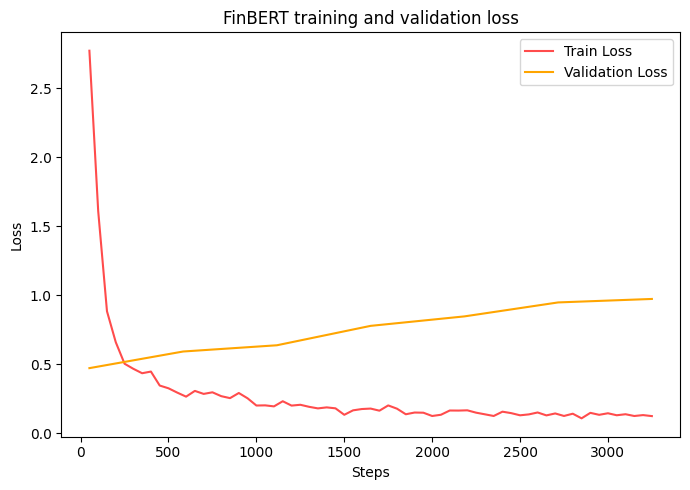

In [113]:
plt.figure(figsize = (7, 5))
# Loss curve
plt.plot(train_steps, train_loss, label = 'Train Loss', color = 'red', alpha = 0.7)
if eval_loss:
    eval_step_pos = np.linspace(min(train_steps), max(train_steps), len(eval_loss))
    plt.plot(eval_step_pos, eval_loss, label = 'Validation Loss',
                 color = 'orange')
plt.title("FinBERT training and validation loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("finbert_loss.png", bbox_inches = 'tight')
plt.show()

### Confusion Matrix Comparison for ML and DL Models

In [134]:
def model_plots(cm1, cm2, name1, name2, filename):
    fig, axes = plt.subplots(1, 2, figsize = (14, 6))
    labels = ["Negative", "Neutral", "Positive"]

    sns.heatmap(cm1, annot = True, fmt = 'd', cmap = "Blues",
                xticklabels = labels, yticklabels = labels, ax = axes[0])
    axes[0].set_title(name1)
    axes[0].set_xlabel("Predicted Label")
    axes[0].set_ylabel("True Label")

    sns.heatmap(cm2, annot = True, fmt = 'd', cmap = "Blues",
                xticklabels = labels, yticklabels = labels, ax = axes[1])
    axes[1].set_title(name2)
    axes[1].set_xlabel("Predicted Label")
    axes[1].set_ylabel("True Label")
    fig.suptitle(f"{name1} vs {name2} : Confusion Matrix Comparison")
    plt.tight_layout()
    plt.savefig(f"{filename}.png")
    plt.show()

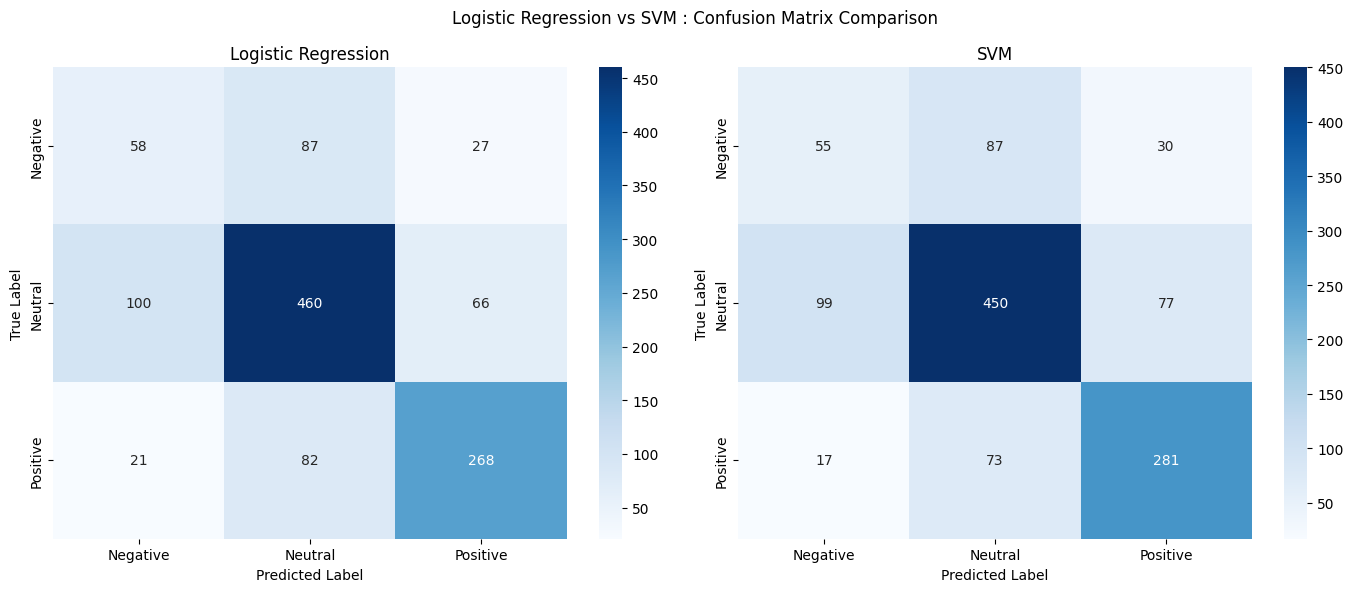

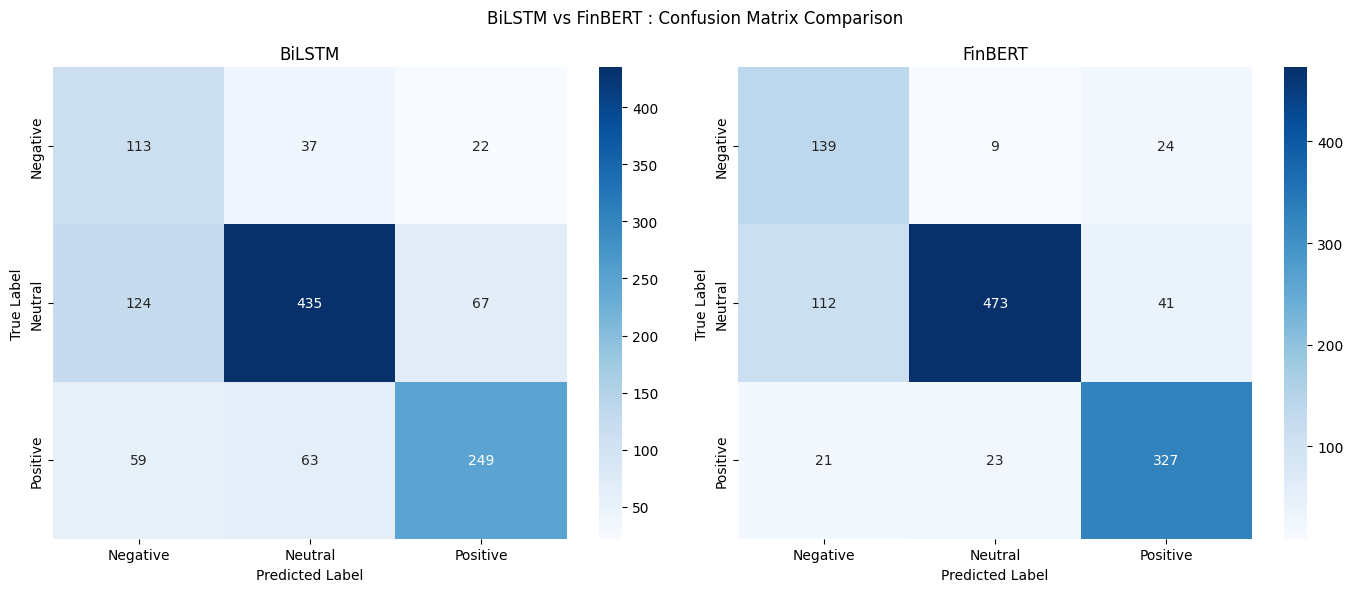

In [135]:
# ML-ML vs DL-DL
model_plots(cm_lr, cm_svm, "Logistic Regression", "SVM", "ML_models")
model_plots(cm_lstm, cm_fin, "BiLSTM", "FinBERT", "DL_models")

### Per-Class F1 Score Comparison
F1 breakdown for each individual class (Negative, Neutral, Positive) across all four models. This demonstrates which models handle minority classes well and which rely too heavily on the majority class.


In [136]:
# Per-class F1 scores for all 4 models
class_labels = ["Negative", "Neutral", "Positive"]
per_class = {
    "LR":      f1_score(y_test, lr_pred, labels = [0, 1, 2], average = None),
    "SVM":     f1_score(y_test, svm_pred, labels = [0, 1, 2], average = None),
    "BiLSTM":  f1_score(y_test, y_pred_bilstm, labels = [0, 1, 2], average = None),
    "FinBERT": f1_score(y_test_ds, finbert_pred, labels = [0, 1, 2], average = None),
}
per_class_df = pd.DataFrame(per_class, index = class_labels).T  # Converting to data frame
per_class_df.columns = [f"F1 - {c}" for c in class_labels]
print(per_class_df.round(4))

         F1 - Negative  F1 - Neutral  F1 - Positive
LR              0.3305        0.7331         0.7322
SVM             0.3207        0.7282         0.7404
BiLSTM          0.4829        0.7494         0.7024
FinBERT         0.6261        0.8364         0.8571


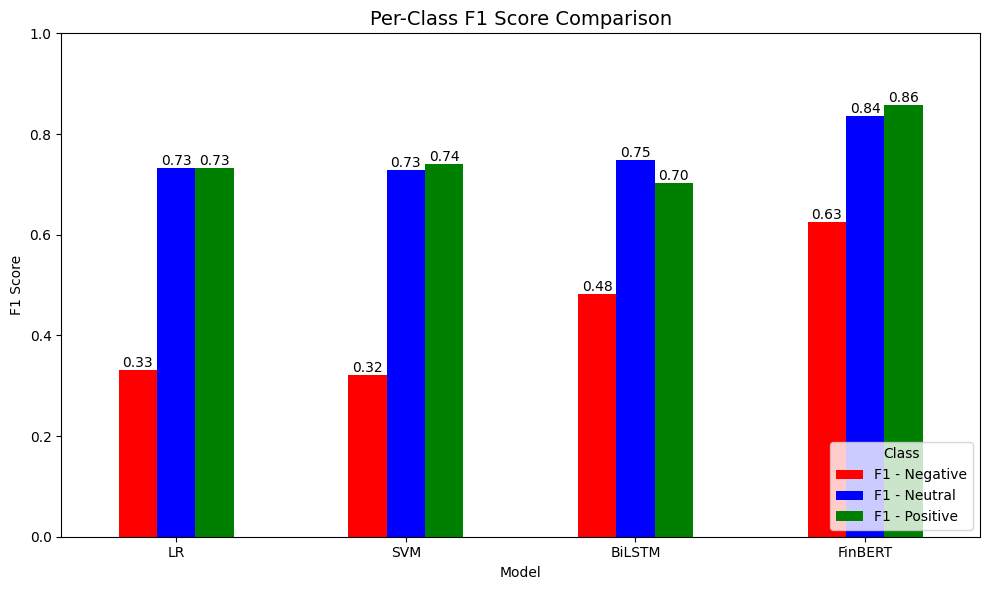

In [141]:
# Comparing all the models from each class
fig, ax = plt.subplots(figsize = (10, 6))
per_class_df.plot(kind = 'bar', ax = ax, color = ['red', 'blue', 'green'])

ax.set_title("Per-Class F1 Score Comparison", fontsize = 14)
ax.set_ylabel("F1 Score")
ax.set_xlabel("Model")
ax.set_ylim(0, 1.0)
ax.set_xticklabels(per_class_df.index, rotation = 0)
ax.legend(title = "Class", loc = 'lower right')

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha = 'center', va = 'bottom')

plt.tight_layout()
plt.savefig("per_class_f1_comparison.png", bbox_inches = 'tight')
plt.show()

### Overall Model Comparison (Accuracy vs Macro F1)
Accuracy vs Macro F1 for all models. A  benchmark line at **F1 = 0.80** is drawn on the F1 chart to show which models performs the closest to it.

In [138]:
# Overall Accuracy and Macro F1 for each model
results_df = pd.DataFrame({
    "Model": ["LR", "SVM", "BiLSTM", "FinBERT"],
    "Accuracy": [acc_lr, acc_svm, acc_lstm, acc_fin],
    "Macro F1": [f1_lr, f1_svm, f1_lstm, f1_fin]
})

print(results_df)

     Model  Accuracy  Macro F1
0       LR  0.672370  0.598597
1      SVM  0.672370  0.596434
2   BiLSTM  0.681779  0.644886
3  FinBERT  0.803251  0.773232


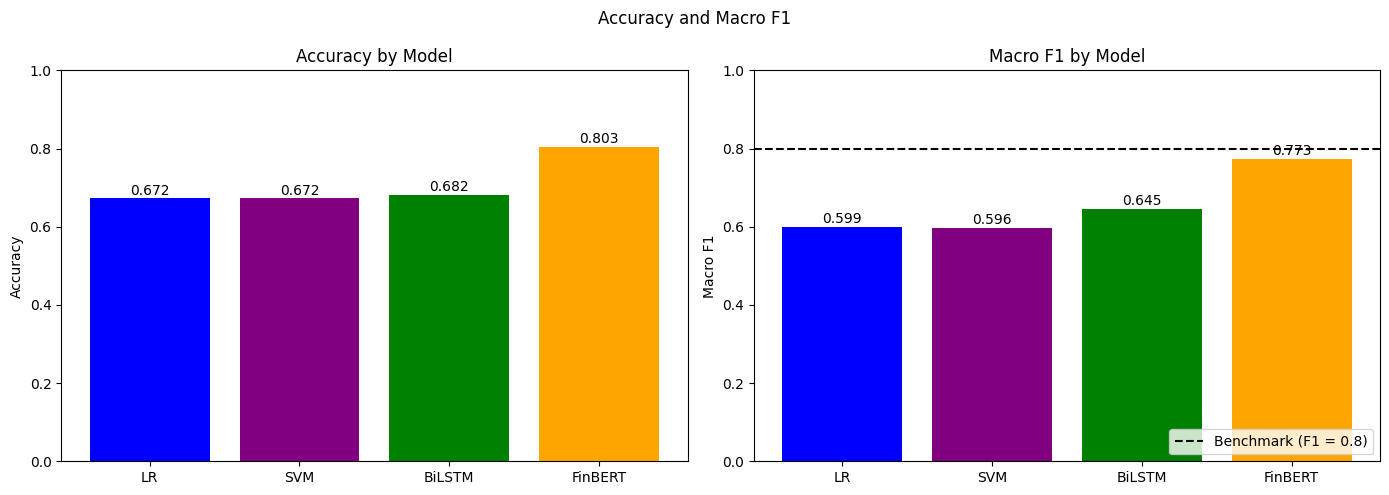

In [139]:
# Accuracy vs Macro F1
f1_benchmark = 0.80

fig, axes = plt.subplots(1, 2, figsize = (14, 5))
bar_colors = ['blue', 'purple', 'green', 'orange']

# Accuracy
axes[0].bar(results_df["Model"], results_df["Accuracy"], color = bar_colors)
axes[0].set_title("Accuracy by Model")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1.0)
for i, v in enumerate(results_df["Accuracy"]):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha = 'center')

# Macro F1 with the 0.78 benchmark
axes[1].bar(results_df["Model"], results_df["Macro F1"], color = bar_colors)
axes[1].axhline(f1_benchmark, color = 'black', linestyle = '--',
                label = f"Benchmark (F1 = {f1_benchmark})")
axes[1].set_title("Macro F1 by Model")
axes[1].set_ylabel("Macro F1")
axes[1].set_ylim(0, 1.0)
axes[1].legend(loc = 'lower right')
for i, v in enumerate(results_df["Macro F1"]):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha = 'center')

fig.suptitle("Accuracy and Macro F1")
plt.tight_layout()
plt.savefig("model_comparison_acc_f1.png", bbox_inches = 'tight')
plt.show()

In [140]:
df.to_csv("processed_data.csv", index = False)